In [196]:
bite_type = "p" # p np total

if bite_type == "total":
    category = "Total"
elif bite_type == "p":
    category = "Poisonous"
else:
    category = "Non-poisonous"

In [51]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import calendar
import seaborn as sns
import os
import matplotlib.ticker as plticker

In [52]:
proc_data_folder = "../proc_data"
case_df = pd.read_csv(os.path.join(proc_data_folder, 'districts.csv'), dtype={"organisationunitcode": str})
geom_df = gpd.read_file(os.path.join(proc_data_folder, "geom_processed.geojson"))
geom_df["organisationunitcode"] = geom_df._match_key.str.split(' ', expand=True)[0]

In [61]:
# --- Configuration ---
YEARS = np.linspace(2015, 2025, 11, dtype = int)

SEASON_MONTHS = {
    'winter': [12, 1, 2],
    'pre': [3, 4],
    'monsoon': [5, 6, 7, 8],
    'post': [9, 10, 11],
}

In [62]:
k = case_df[["organisationunitcode","population"]].groupby(["organisationunitcode"], as_index=False).mean()
k = geom_df.merge(
    k,
    left_on=["organisationunitcode"],
    right_on=["organisationunitcode"],
    how='left'
)
k.head(2)

,OBJECTID,STATE_CODE,DISTRICT,GaPa_NaPa,Type_GN,Province,Area,Shape_Leng,Shape_Area,elev_mean,elev_max,_match_key,geometry,organisationunitcode,population
0,1,7,DOTI,Adharsha,Gaunpalika,Sudur Pashchim,0.0,282908.088904,2.054599e+09,1502.189801,3286.547363,706 DOTI,"POLYGON ((81.03282 29.1862, 81.03295 29.18651,...",706,208856.031250
1,2,3,RAMECHHAP,Doramba,Gaunpalika,Bagmati,0.0,295289.035440,1.565522e+09,2079.053268,6804.967285,310 RAMECHHAP,"POLYGON ((86.22432 27.38306, 86.22421 27.38301...",310,188015.171875


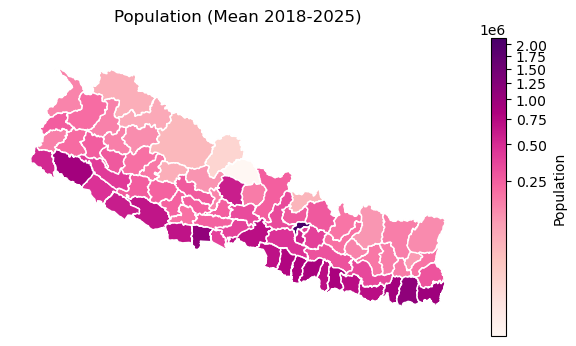

In [63]:
ax = k.plot(
    column="population",
    cmap="RdPu",
    legend=True,
    legend_kwds={"label": "Population", "orientation": "vertical", "fraction": 0.03},
    norm=mcolors.PowerNorm(gamma=0.3),
    edgecolor='white'
)
ax.set_title("Population (Mean 2018-2025)", pad=25)
ax.set_axis_off()

plt.savefig(os.path.join("../outputs/figures", 'pop_map.png'), dpi=150, bbox_inches='tight')

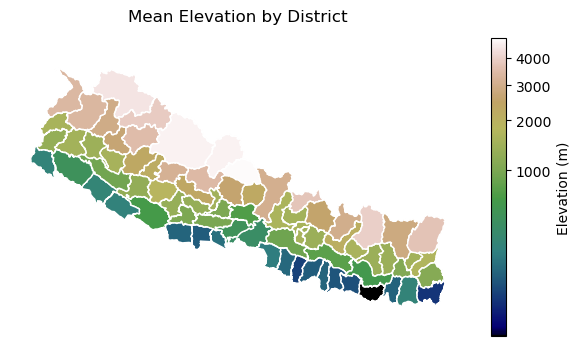

In [65]:
ax = k.plot(
    column="elev_mean",
    cmap="gist_earth",
    legend=True,
    legend_kwds={"label": "Elevation (m)", "orientation": "vertical", "fraction": 0.03},
    norm=mcolors.PowerNorm(gamma=0.35),
    edgecolor='white'
)
ax.set_title("Mean Elevation by District", pad=25)
ax.set_axis_off()

plt.savefig(os.path.join("../outputs/figures", 'elev_map.png'), dpi=150, bbox_inches='tight')

In [66]:
def assign_season(month: int) -> str:
    """Map a month integer to its season label."""
    for season, months in SEASON_MONTHS.items():
        if month in months:
            return season
    raise ValueError(f"Month {month} not found in any season definition.")

def assign_season_year(row) -> int:
    """
    Assign the 'season year' — the year a season is labelled by.
    Winter spans December–February, so December belongs to the *next*
    year's winter (e.g. Dec 2022 → winter 2023).
    All other seasons use the calendar year of the month.
    """
    if row['month_num'] == 12:
        return row['year'] + 1
    return row['year']

def resample_to_seasons(df: pd.DataFrame) -> pd.DataFrame:
    """
    Resample a long-format timeseries to seasonal aggregates.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns:
          - month              : datetime-like
          - organisationunitid : facility/org unit identifier
          - organisationunitname, province_name, province_code,
            organisationunitcode : metadata (kept as-is)
          - p_cases, np_cases  : case counts to sum
          - population         : used to compute rates per 100k

    Returns
    -------
    pd.DataFrame
        One row per (organisationunitid, season_year, season) with:
          - p_cases_sum, np_cases_sum
          - total_cases_sum
          - p_cases_rate, np_cases_rate, total_cases_rate  (per 100k)
          - months_in_season   : how many monthly records contributed
    """
    df = df.copy()

    # --- Parse timestamps ---
    df['month'] = pd.to_datetime(df['month'])
    df['month_num'] = df['month'].dt.month
    df['year'] = df['month'].dt.year

    # --- Assign season labels and season years ---
    df['season'] = df['month_num'].map(assign_season)
    df['season_year'] = df.apply(assign_season_year, axis=1)

    # --- Aggregate ---
    group_keys = [
        'organisationunitid',
        'organisationunitname',
        'province_name',
        'province_code',
        'organisationunitcode',
        'season_year',
        'season',
    ]

    agg = df.groupby(group_keys, observed=True).agg(
        p_cases_sum=('p_cases', 'sum'),
        np_cases_sum=('np_cases', 'sum'),
        population=('population', 'first'),
        months_in_season=('month', 'count'),
    ).reset_index()

    agg['total_cases_sum'] = agg['p_cases_sum'] + agg['np_cases_sum']

    # --- Rates per 100k ---
    for col in ['p_cases', 'np_cases', 'total_cases']:
        agg[f'{col}_rate'] = (agg[f'{col}_sum'] / agg['population']) * 100_000

    # --- Categorical season order ---
    season_order = ['winter', 'pre', 'monsoon', 'post']
    agg['season'] = pd.Categorical(agg['season'], categories=season_order, ordered=True)
    agg = agg.sort_values(['organisationunitid', 'season_year', 'season']).reset_index(drop=True)

    return agg

In [67]:
result = resample_to_seasons(case_df)
result.head(2)

,organisationunitid,organisationunitname,province_name,province_code,organisationunitcode,season_year,season,p_cases_sum,np_cases_sum,population,months_in_season,total_cases_sum,p_cases_rate,np_cases_rate,total_cases_rate
0,A3R7UT64jHf,206 RAUTAHAT,2 Madhesh Province,2,206,2015,pre,5.0,146.0,817585.0,1,151.0,0.611557,17.857470,18.469028
1,A3R7UT64jHf,206 RAUTAHAT,2 Madhesh Province,2,206,2015,monsoon,6.0,303.0,817585.0,4,309.0,0.733869,37.060367,37.794235


In [71]:
YEARS_subset = [YEARS[i] for i in [0,5,10]]
YEARS_subset

[np.int64(2015), np.int64(2020), np.int64(2025)]

In [72]:
gdf = geom_df[['organisationunitcode', 'geometry', 'elev_mean']].merge(
    result,
    on='organisationunitcode',
    how='inner'
)

gdf = gpd.GeoDataFrame(gdf, geometry='geometry')
gdf.tail(2)

,organisationunitcode,geometry,elev_mean,organisationunitid,organisationunitname,province_name,province_code,season_year,season,p_cases_sum,np_cases_sum,population,months_in_season,total_cases_sum,p_cases_rate,np_cases_rate,total_cases_rate
3309,501,"POLYGON ((82.97442 28.62608, 82.97445 28.62603...",3161.43651,zkFZKX5RX1A,501 RUKUM EAST,5 Lumbini Province,5,2025,monsoon,8.0,9.0,56002.0,4,17.0,14.285204,16.070855,30.356059
3310,501,"POLYGON ((82.97442 28.62608, 82.97445 28.62603...",3161.43651,zkFZKX5RX1A,501 RUKUM EAST,5 Lumbini Province,5,2025,post,1.0,1.0,56002.0,3,2.0,1.785651,1.785651,3.571301


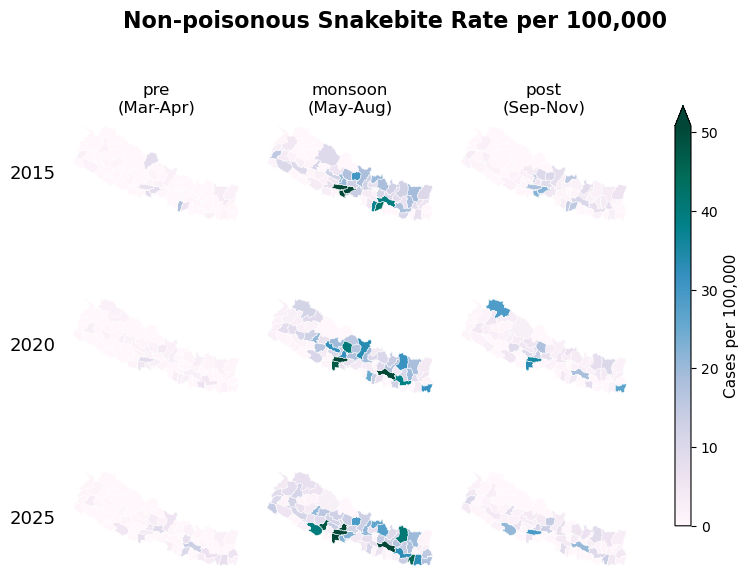

In [79]:
cmap = 'PuBuGn'
SEASONS = ['pre', 'monsoon', 'post']

case_rate_col = bite_type + "_cases_rate"

# --- Shared color scale across all subplots ---
# Filter to only the years/seasons we'll plot, then compute robust scale
plot_mask = (
    gdf['season_year'].isin(YEARS_subset) &
    gdf['season'].isin(SEASONS)
)

vmin = np.nanpercentile(gdf.loc[plot_mask, case_rate_col], 5)
vmax = np.nanpercentile(gdf.loc[plot_mask, case_rate_col], 99)

# --- Plot ---
fig, axes = plt.subplots(len(YEARS_subset), len(SEASONS), figsize=(8, 6))
fig.suptitle(category + ' Snakebite Rate per 100,000', fontsize=16, fontweight='bold', y=1.01)

for i, year in enumerate(YEARS_subset):
    for j, season in enumerate(SEASONS):
        ax = axes[i][j]

        subset = gdf[(gdf['season_year'] == year) & (gdf['season'] == season)]

        subset.plot(
            column=case_rate_col,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolor='white',
            linewidth=0.3,
            missing_kwds={'color': 'lightgrey'},
        )

        if j == 0:
            ax.annotate(str(year), xy=(-0.05, 0.5), xycoords='axes fraction',
                        fontsize=13, va='center', ha='right', rotation=0)

        ax.axis('off')

# --- Column headers (season labels with month range) ---
for ax, season in zip(axes[0], SEASONS):
    months = SEASON_MONTHS[season]
    label = season + "\n" + f"({calendar.month_abbr[months[0]]}-{calendar.month_abbr[months[-1]]})"
    ax.set_title(label)

# --- Shared colorbar ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
plt.tight_layout()
plt.subplots_adjust(hspace=0.05, right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax, extend='max')
cbar.set_label('Cases per 100,000', fontsize=11)

plt.savefig(os.path.join("../outputs/figures", category.lower() + '_seasonal_rates_map.png'), dpi=150, bbox_inches='tight')
plt.show()

In [197]:
cols_sub = ["season_year", "season", "p_cases_sum", "np_cases_sum", "total_cases_sum", "population"]

In [198]:
gdf['elev_q'] = pd.qcut(gdf['elev_mean'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
x = gdf[cols_sub + ["elev_q"]].groupby(["season_year", "season", "elev_q"]).sum().reset_index()

x["case_rate"] = x[bite_type + "_cases_sum"] / x["population"] * 100000
x["xlab"] = x["season_year"].astype('string') + x["season"].astype('string')
x.head(5)

,season_year,season,elev_q,p_cases_sum,np_cases_sum,total_cases_sum,population,case_rate,xlab
0,2015,pre,Q1,35.0,301.0,336.0,14587034.0,0.239939,2015pre
1,2015,pre,Q2,9.0,39.0,48.0,5634657.0,0.159726,2015pre
2,2015,pre,Q3,9.0,16.0,25.0,6627618.0,0.135795,2015pre
3,2015,pre,Q4,0.0,21.0,21.0,2584582.0,0.000000,2015pre
4,2015,monsoon,Q1,189.0,1707.0,1896.0,14587034.0,1.295671,2015monsoon


In [199]:
y = (gdf[cols_sub]).groupby(["season_year", "season"]).sum().reset_index()
y["case_rate"] = y[bite_type + "_cases_sum"] / y["population"] * 100000
y["xlab"] = y["season_year"].astype('string') + y["season"].astype('string')
y.head(10)

,season_year,season,p_cases_sum,np_cases_sum,total_cases_sum,population,case_rate,xlab
0,2015,pre,53.0,377.0,430.0,29433891.0,0.180065,2015pre
1,2015,monsoon,394.0,3057.0,3451.0,29433891.0,1.338593,2015monsoon
2,2015,post,99.0,973.0,1072.0,29433891.0,0.336347,2015post
3,2016,winter,79.0,170.0,249.0,29433891.0,0.268398,2016winter
4,2016,pre,50.0,341.0,391.0,29433891.0,0.169872,2016pre
5,2016,monsoon,487.0,3946.0,4433.0,29433891.0,1.654555,2016monsoon
6,2016,post,231.0,1259.0,1490.0,29433891.0,0.784810,2016post
7,2017,winter,37.0,223.0,260.0,29433891.0,0.125705,2017winter
8,2017,pre,142.0,702.0,844.0,29433891.0,0.482437,2017pre
9,2017,monsoon,413.0,3032.0,3445.0,29433891.0,1.403144,2017monsoon


In [200]:
ranges = {}
for i, (e_min, e_max) in enumerate(zip(
    gdf[["elev_q", "elev_mean"]].groupby(["elev_q"]).min().elev_mean,
    gdf[["elev_q", "elev_mean"]].groupby(["elev_q"]).max().elev_mean)):
    ranges[i+1] = (int(e_min), int(e_max))

ranges

{1: (108, 461), 2: (569, 1390), 3: (1445, 2558), 4: (2604, 4838)}

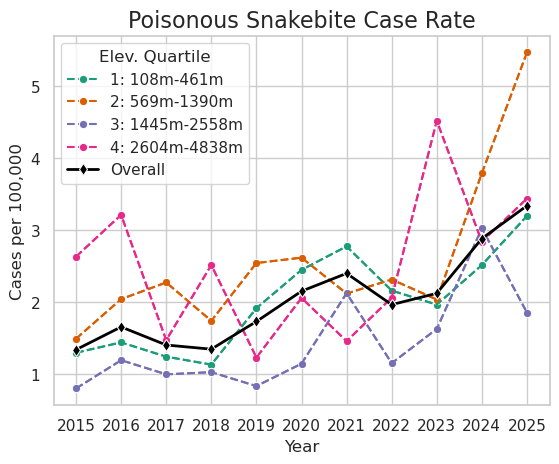

In [201]:
sns.set_theme(style="whitegrid")
r_fmt = "{i}: {e_min}m-{e_max}m"
leg_labs = [r_fmt.format(i = i+1, e_min = r[0], e_max = r[1]) for i, r in enumerate(ranges.values())]
leg_labs.append("Overall")
pal = "Dark2"

fig, ax = plt.subplots()

sns.lineplot(
    data=x[x["season"]=="monsoon"], x="xlab", y="case_rate", hue="elev_q",
    palette = pal, marker="o",
    err_style="bars"
)

#ax.lines[0].set_linestyle("--")
    
## Using collections
# plt.setp(ax.collections, alpha=0.15)
plt.setp(ax.lines, linestyle="dashed")

sns.lineplot(data=y[y["season"]=="monsoon"],
             color ="black",
             x="xlab",
             y="case_rate",
             lw=2, marker="d",
             label='Overall', zorder=1000)

plt.xticks(np.arange(11), YEARS)
plt.title(category + ' Snakebite Case Rate', fontsize=16)
plt.xlabel("Year")
plt.ylabel("Cases per 100,000")

# Get the handles and labels
handles, labels = ax.get_legend_handles_labels()

# Pass the original handles and the new labels to legend()
ax.legend(handles, leg_labs, loc='best', title="Elev. Quartile")

plt.savefig(os.path.join("../outputs/figures", category.lower() + '_mons_by_elev_quartile.png'),
            dpi=150, 
            bbox_inches='tight')
plt.show()

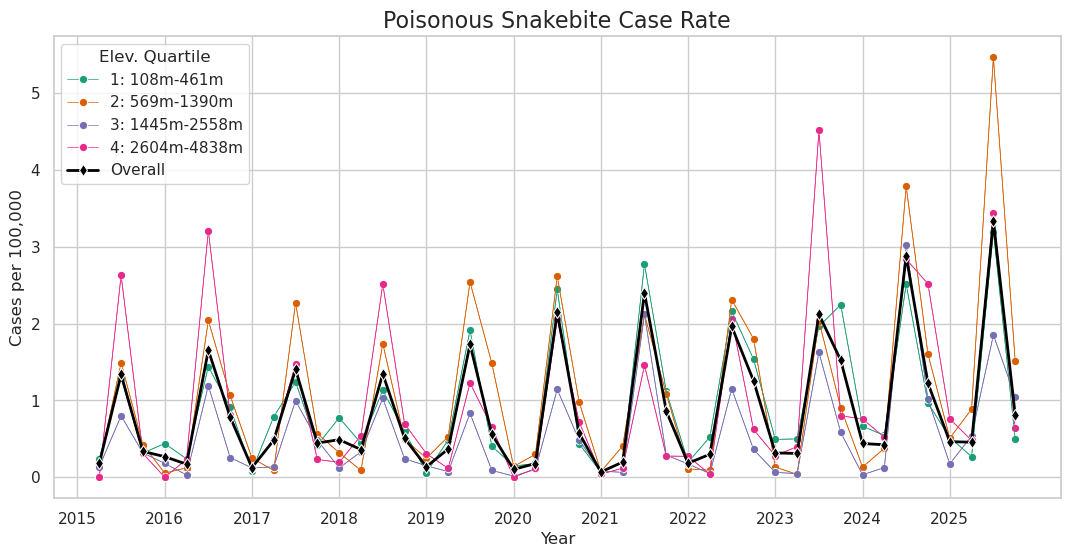

In [202]:
sns.set_theme(style="whitegrid")
r_fmt = "{i}: {e_min}m-{e_max}m"
leg_labs = [r_fmt.format(i = i+1, e_min = r[0], e_max = r[1]) for i, r in enumerate(ranges.values())]
leg_labs.append("Overall")
pal = "Dark2"

fig, ax = plt.subplots(figsize=(13, 6))

# data=x[x["season"]=="monsoon"]
sns.lineplot(
    data=x, x="xlab", y="case_rate", hue="elev_q",
    palette = pal, marker="o",
    err_style="bars"
)

#ax.lines[0].set_linestyle("..")
    
## Using collections
# plt.setp(ax.collections, alpha=0.15)
plt.setp(ax.lines, linestyle="solid", linewidth = 0.5)

# data=y[y["season"]=="monsoon"],
sns.lineplot(data=y,
             color ="black",
             x="xlab",
             y="case_rate",
             lw=2, marker="d",
             label='Overall', zorder=1000)

plt.xticks(np.arange(-1, 43, 4), YEARS)
plt.title(category + ' Snakebite Case Rate', fontsize=16)
plt.xlabel("Year")
plt.ylabel("Cases per 100,000")

# Get the handles and labels
handles, labels = ax.get_legend_handles_labels()

# Pass the original handles and the new labels to legend()
ax.legend(handles, leg_labs, loc='best', title="Elev. Quartile")

plt.savefig(os.path.join("../outputs/figures", category.lower() + '_all_by_elev_quartile.png'),
            dpi=150, 
            bbox_inches='tight')
plt.show()

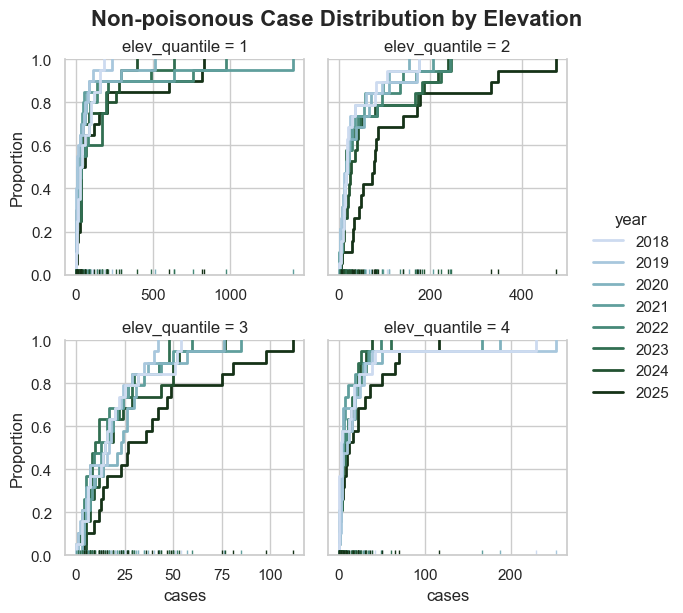

In [257]:
sns.set_theme(style="whitegrid")
pal = sns.cubehelix_palette(8, start=1.76)

ax = sns.displot(
    z,
    x="cases", col="elev_quantile", col_wrap = int(q/2), hue="year", 
    kind="ecdf", aspect=1, height = 3, linewidth=2, palette=pal, rug = True,
    facet_kws={"sharex": False}
)

ax.despine(right=False)
ax.figure.subplots_adjust(wspace=0.1)
plt.suptitle(category + ' Case Distribution by Elevation', fontsize=16, fontweight='bold', y=1.02)

plt.savefig(os.path.join("figures", category.lower() + '_summer_dist_by_elev.png'),
            dpi=150, 
            bbox_inches='tight')

plt.show()